### 7-6-2026

0000 | train 0.3257 | test 0.1869 | phys 0.7142 
0250 | train 0.0004 | test 0.0005 | phys 0.7595 
0500 | train 0.0002 | test 0.0001 | phys 0.7599 
0750 | train 0.0001 | test 0.0002 | phys 0.7599 
1000 | train 0.0001 | test 0.0001 | phys 0.7596 


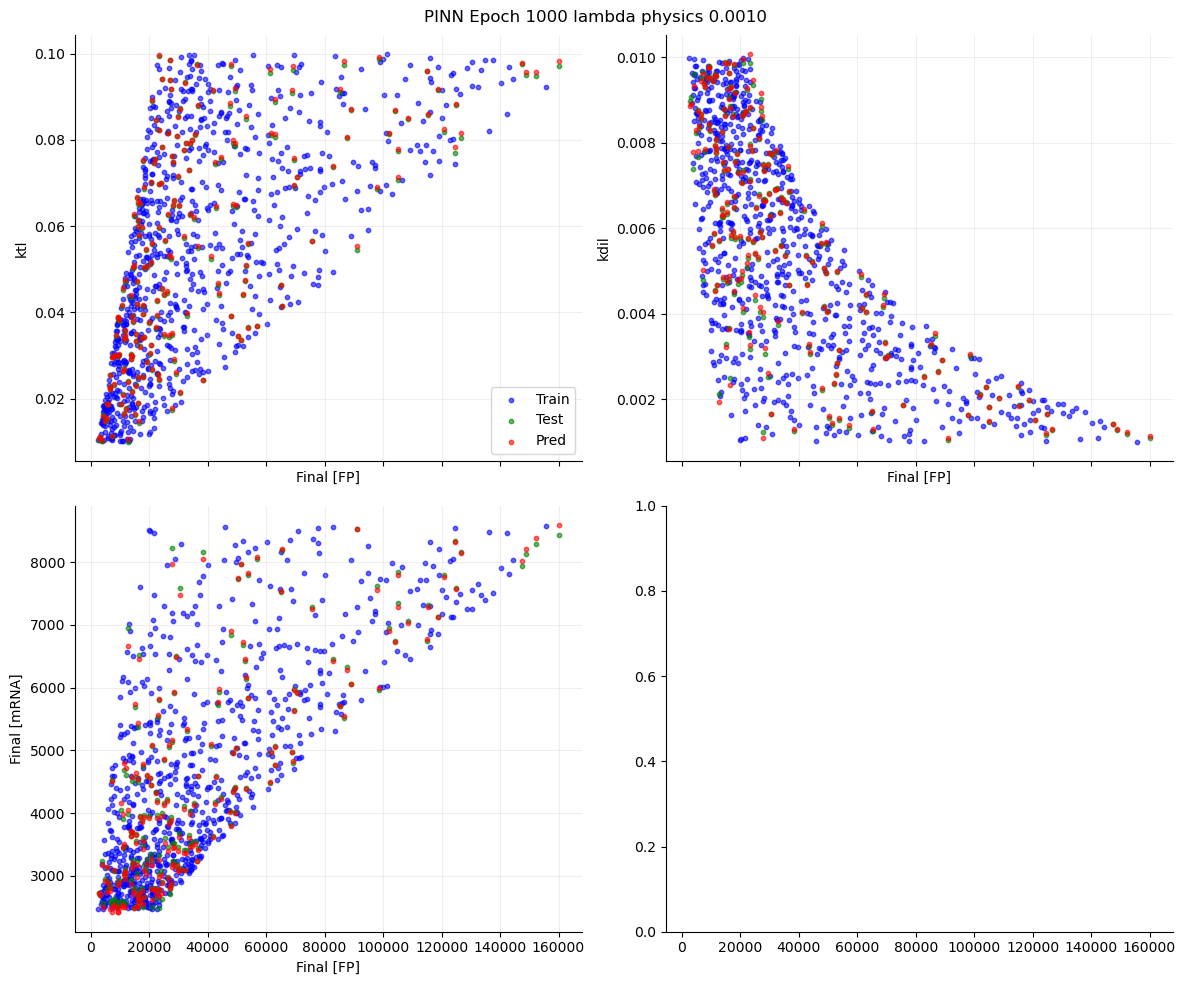

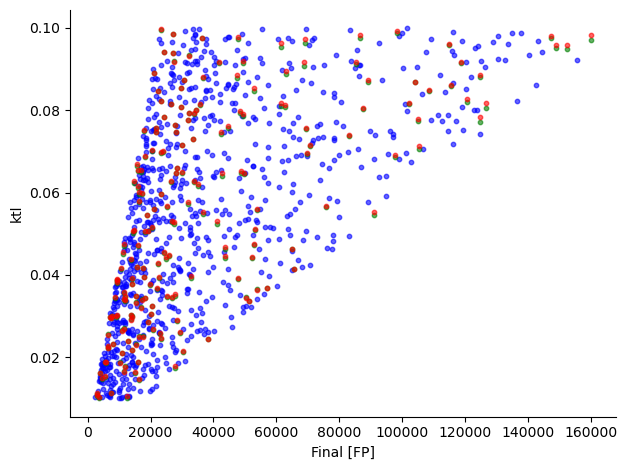

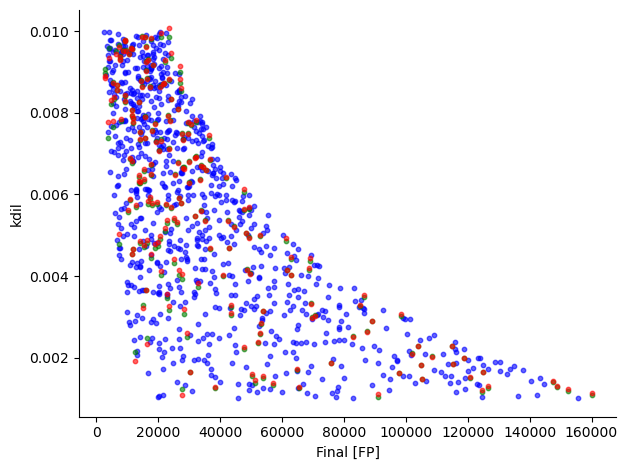

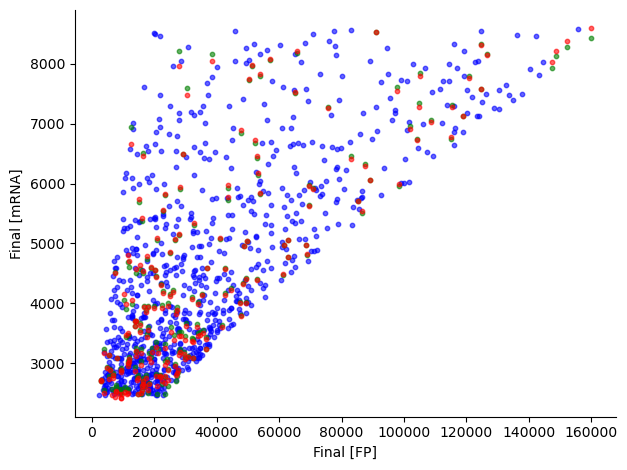

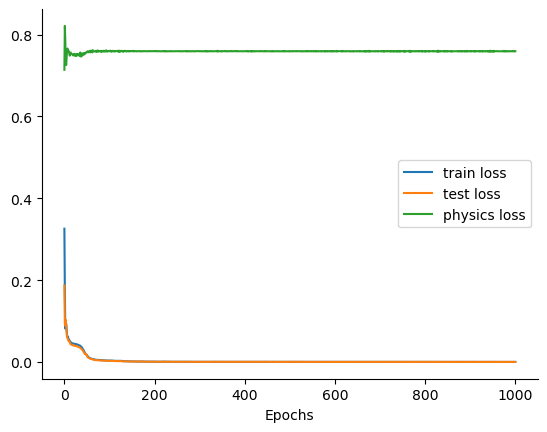

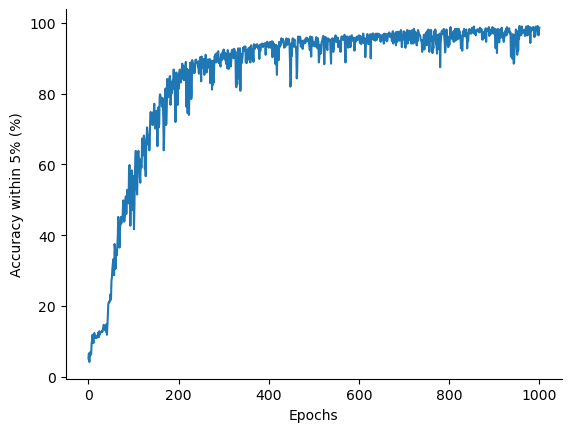


ktl: within 5% accuracy =99.50%
ktl: within 10% accuracy =100.00%
ktl: within 25% accuracy =100.00%

kdil: within 5% accuracy =97.00%
kdil: within 10% accuracy =99.50%
kdil: within 25% accuracy =100.00%

mRNA: within 5% accuracy =99.50%
mRNA: within 10% accuracy =100.00%
mRNA: within 25% accuracy =100.00%

Overall Accuracy within 5%: 98.67%
Accuracy:  98.66666595141093


In [3]:
import sys
import os
import numpy as np
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt

PROJECT_ROOT = os.path.abspath("..")
sys.path.append(PROJECT_ROOT)

mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False

import NNs.PINN_v3 as NN

X_lst = np.load("../Simulations/sim_TU_data/yfp_culture.npy")
Y_lst = np.load("../Simulations/sim_TU_data/param_labels_culture.npy")
# time_lst = np.load("../../Simulations/sim_TU_data/time_culture.npy")
# mrna = np.load("../../Simulations/sim_TU_data/mrna_culture.npy")

# P = X_lst
# dt = time_lst[-1] - time_lst[-2]

# # dP = np.zeros_like(P)
# dP = [np.gradient(P[i], dt) for i in range(P.shape[0])]
# dP = np.array(dP)

# print(mrna.shape)
# print(dP.shape)

# ktl = Y_lst[:, 0]
# kdil = Y_lst[:, 1]

# print(ktl.shape)
# print(ktl)

# # ktl = np.expand_dims(ktl, 1)
# # kdil = np.expand_dims(kdil, 1)

# print(ktl.shape)

# # 0 = (ktl * M) - (kdil * A) - dAdt
# eps = 1e-6
# res = ktl @ mrna - kdil @ P - (dP)
# scale1 = (ktl @ mrna) + (kdil @ P) + dP + eps
# loss_phys = (res / scale1)

# print(res)
# print(loss_phys)

torch.manual_seed(308380)

model = NN.PINN(n_epochs=1001, p_epoch=250, lr=0.009, weight_decay=0, 
                     lambda_phys=0.001, hidden_dim=64, phys_start_epoch=0)

model.fit(X_lst, Y_lst, batch_size=200)
model.plot_loss()
epochs, accuracies = model.plot_accuracy()   
acc = model.predict()

print('Accuracy: ', acc)
